## AR to ARIMA

We will begin with univariate analysis.


In [1]:
import pandas as pd

finsec_data=pd.read_csv('../feature_engineering/stocks_sectors/financial_services/financial_services_sector')

finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


In [2]:
fin_data=finsec_data[['date','weighted_sector_returns']]
fin_data

,date,weighted_sector_returns
0,2017-01-03,0.000000
1,2017-01-04,0.353432
2,2017-01-05,-0.182223
3,2017-01-06,1.397196
4,2017-01-09,3.645896
...,...,...
2258,2026-07-13,-0.746327
2259,2026-07-14,0.906947
2260,2026-07-15,0.779799
2261,2026-07-16,1.505893


We have to ensure this is a stationary data (no trend)

In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(fin_data['weighted_sector_returns'])
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-13.191191464558408), np.float64(1.143191313494307e-24), 8, 2254, {'1%': np.float64(-3.43325450880204), '5%': np.float64(-2.862823135013053), '10%': np.float64(-2.567453072861103)}, np.float64(8389.703138052395))
stationary


In [4]:
fin_data['weighted_sector_returns'].describe()

count    2263.000000
mean        0.160621
std         1.605039
min       -13.106859
25%        -0.510407
50%         0.058116
75%         0.767203
max         9.392698
Name: weighted_sector_returns, dtype: float64

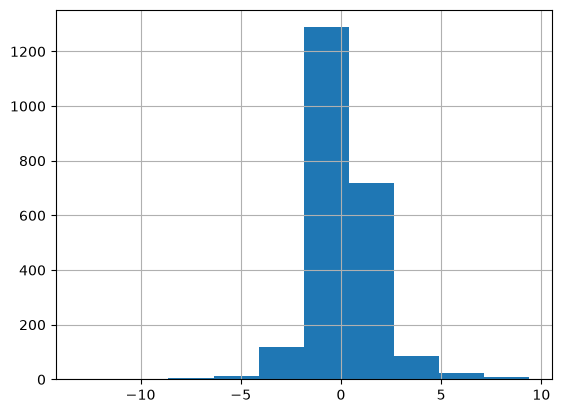

In [5]:
import matplotlib.pyplot as plt
ax=fin_data['weighted_sector_returns'].hist()

plt.show()

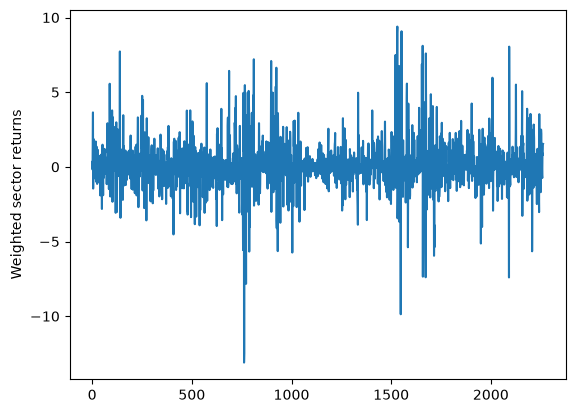

In [6]:
import matplotlib.pyplot as plt
ax=fin_data['weighted_sector_returns'].plot()
ax.set_ylabel('Weighted sector returns')
plt.show()

In [7]:
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     2263 non-null   str    
 1   weighted_sector_returns  2263 non-null   float64
dtypes: float64(1), str(1)
memory usage: 35.5 KB


In [8]:
fin_data['date']=pd.to_datetime(fin_data['date'])
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   weighted_sector_returns  2263 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 35.5 KB


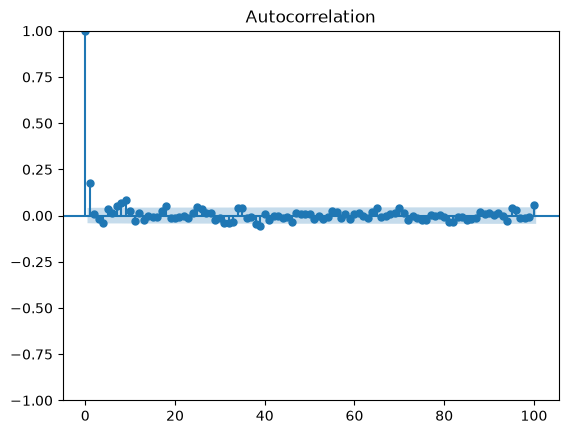

In [14]:
# Autocorrelation of the differenced data
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
plot_acf(fin_data['weighted_sector_returns'], lags=100) ## acf is short for autocorrelation function
plt.show()

Lags with 1, 8, 9, 18, 39, 100 have significant autocorrelation

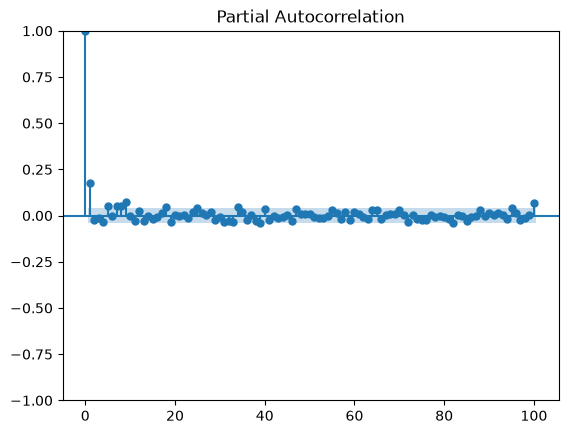

In [15]:
## partial autocorrelation
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(fin_data['weighted_sector_returns'], lags = 100)
plt.show()

In [16]:
# Estimate Yule-Walker AR coefficients with order 20
from statsmodels.regression.linear_model import yule_walker

coefficients, sigma = yule_walker(fin_data['weighted_sector_returns'], order = 20)

print('coefficients: ', -coefficients)
print('sigma: ', sigma)

coefficients:  [-0.17604882  0.02637502  0.00597369  0.04328665 -0.05497302  0.0084761
 -0.04276545 -0.04203294 -0.06590152 -0.00611985  0.03641016 -0.03158318
  0.03122695 -0.00719265  0.0187755   0.0100623  -0.00579487 -0.05113925
  0.03352949 -0.00174884]
sigma:  1.5634230396878819


In [19]:
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   weighted_sector_returns  2263 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 35.5 KB


In [ ]:
from sklearn.metrics import r2_score

# Apply a grid search to find the order that gives the best R2 score on the test data

def evaluate(order):
    train = list(fin_data['weighted_sector_returns'])[:-10]
    test = list(fin_data['weighted_sector_returns'])[-10:]

    coefficients, sigma = yule_walker(train, order = order)

    # Make a list of differenced values
    val_list = list(train)

    # Reverse the list to corresponds with the order of coefs
    val_list.reverse()

    # Define the number of years to predict
    n_steps = 10

    # For each day to predict
    for i in range(n_steps):
        # Compute the new value
        new_val = 0
        for j in range(len(coefficients)):
            new_val += coefficients[j] * val_list[j]

        # Insert the new value at the beginning of the list
        val_list.insert(0, new_val)

    # Redo the reverse to have the order of time
    val_list.reverse()
    new_val_list= val_list

    # Plot the newly obtained list
    test_validation = pd.DataFrame({
        'original': list(fin_data['weighted_sector_returns']),
        'test_pred': new_val_list 
    })
    
    return r2_score(test_validation.iloc[-10:, 0], test_validation.iloc[-10:, 1])



In [24]:
# For each order between 1 and 30, fit and evaluate the model
orders = []
r2scores = []
for order in range(1, 31):
    orders.append(order)
    r2scores.append(evaluate(order))

# Create a results data frame
results =pd.DataFrame({'orders': orders,'scores': r2scores})

# Show the order with best R2 score
results[results['scores'] == results.max()['scores']]

,orders,scores
17,18,-0.101337


The performance is worse than guessing. We will try to use monthly data

In [25]:
fin_data

,date,weighted_sector_returns
0,2017-01-03,0.000000
1,2017-01-04,0.353432
2,2017-01-05,-0.182223
3,2017-01-06,1.397196
4,2017-01-09,3.645896
...,...,...
2258,2026-07-13,-0.746327
2259,2026-07-14,0.906947
2260,2026-07-15,0.779799
2261,2026-07-16,1.505893


In [26]:
finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


To do the monthly returns we have to get the monthly returns and not the daily returns. We will us the sector_index to get this done.

In [28]:
# 2. Filter for rows that land on the final day of the month
finsec_data['date']=pd.to_datetime(finsec_data['date'])
monthly_data = finsec_data[finsec_data['date'].dt.is_month_end]
monthly_data


,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
20,2017-01-31,financial_services,-0.996463,20.0,109.001843,6.143258e+07
40,2017-02-28,financial_services,0.649545,21.0,107.626307,1.659638e+08
63,2017-03-31,financial_services,-0.017945,21.0,105.456849,1.692346e+08
102,2017-05-31,financial_services,-2.338342,21.0,138.127184,1.255609e+08
122,2017-06-30,financial_services,-0.251046,21.0,162.591431,7.823224e+07
...,...,...,...,...,...,...
2124,2025-12-31,financial_services,0.747648,35.0,1802.129757,2.941320e+08
2167,2026-02-28,financial_services,0.000000,35.0,2364.419520,3.839622e+08
2190,2026-03-31,financial_services,-1.878773,35.0,2347.696835,4.722937e+08
2210,2026-04-30,financial_services,1.404651,35.0,2856.819058,1.559131e+09


In [31]:
monthly_fin_data=monthly_data[['date','sector_index']].reset_index()
monthly_fin_data

,index,date,sector_index
0,20,2017-01-31,109.001843
1,40,2017-02-28,107.626307
2,63,2017-03-31,105.456849
3,102,2017-05-31,138.127184
4,122,2017-06-30,162.591431
...,...,...,...
72,2124,2025-12-31,1802.129757
73,2167,2026-02-28,2364.419520
74,2190,2026-03-31,2347.696835
75,2210,2026-04-30,2856.819058


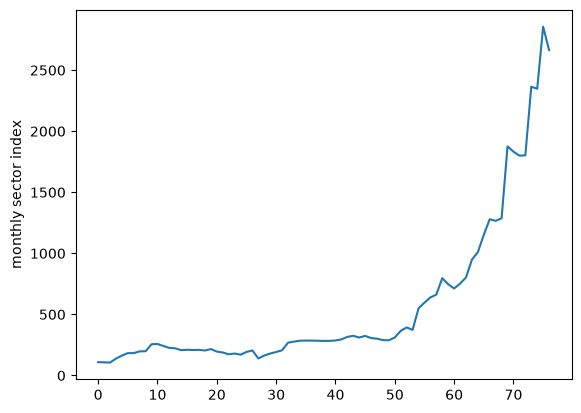

In [32]:
import matplotlib.pyplot as plt
ax=monthly_fin_data['sector_index'].plot()
ax.set_ylabel('monthly sector index')
plt.show()

There is clearly a trend so we will apply differencing.

In [33]:
## Lets check first.
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_fin_data['sector_index'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(3.239421816841054), 1.0, 11, 65, {'1%': np.float64(-3.5352168748293127), '5%': np.float64(-2.9071540828402367), '10%': np.float64(-2.5911025443786984)}, np.float64(734.6996748488009))
not stationary


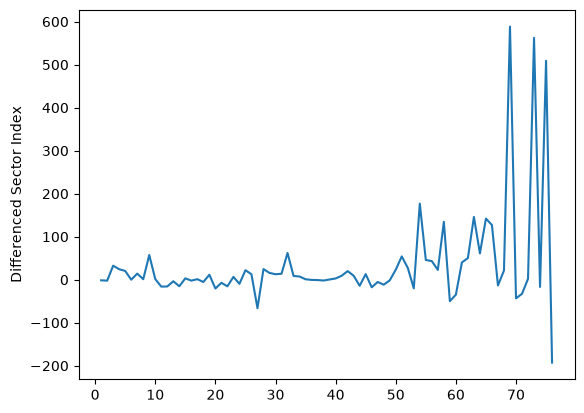

In [34]:
# Difference the data
monthly_fin_data['sector_differenced'] = monthly_fin_data['sector_index'].diff().dropna()

# Plot the differenced data
ax = monthly_fin_data['sector_differenced'].plot()
ax.set_ylabel('Differenced Sector Index')
plt.show()

In [35]:
## Lets check for stationarity
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_fin_data['sector_differenced'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(3.364965410276832), 1.0, 11, 64, {'1%': np.float64(-3.53692771987915), '5%': np.float64(-2.907887369384766), '10%': np.float64(-2.591493291015625)}, np.float64(732.1712992453624))
not stationary


In [36]:
monthly_fin_data

,index,date,sector_index,sector_differenced
0,20,2017-01-31,109.001843,NaN
1,40,2017-02-28,107.626307,-1.375536
2,63,2017-03-31,105.456849,-2.169458
3,102,2017-05-31,138.127184,32.670334
4,122,2017-06-30,162.591431,24.464248
...,...,...,...,...
72,2124,2025-12-31,1802.129757,2.137693
73,2167,2026-02-28,2364.419520,562.289764
74,2190,2026-03-31,2347.696835,-16.722686
75,2210,2026-04-30,2856.819058,509.122223


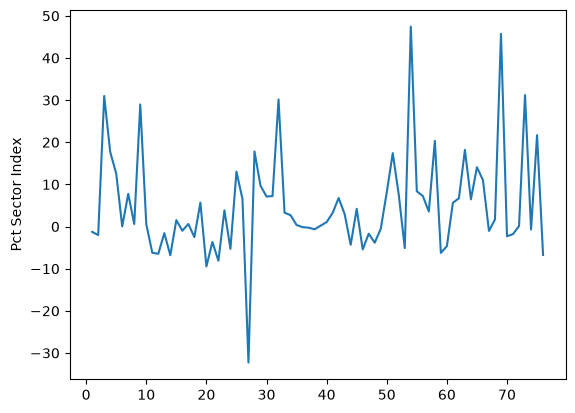

In [38]:
# Difference the data
monthly_fin_data['sector_pct_change'] = monthly_fin_data['sector_index'].pct_change()*100

# Plot the differenced data
ax = monthly_fin_data['sector_pct_change'].plot()
ax.set_ylabel('Pct Sector Index')
plt.show()

In [39]:
monthly_fin_data

,index,date,sector_index,sector_differenced,sector_pct_change
0,20,2017-01-31,109.001843,NaN,NaN
1,40,2017-02-28,107.626307,-1.375536,-1.261938
2,63,2017-03-31,105.456849,-2.169458,-2.015732
3,102,2017-05-31,138.127184,32.670334,30.979813
4,122,2017-06-30,162.591431,24.464248,17.711392
...,...,...,...,...,...
72,2124,2025-12-31,1802.129757,2.137693,0.118761
73,2167,2026-02-28,2364.419520,562.289764,31.201403
74,2190,2026-03-31,2347.696835,-16.722686,-0.707264
75,2210,2026-04-30,2856.819058,509.122223,21.686029


In [40]:
## Lets check for stationarity
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_fin_data['sector_pct_change'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-3.077855004857061), np.float64(0.028236017645485268), 3, 72, {'1%': np.float64(-3.524624466842421), '5%': np.float64(-2.9026070739026064), '10%': np.float64(-2.5886785262345677)}, np.float64(496.0283044748153))
stationary


The sector_percent change is stationary. We will work with it

In [41]:
monthly_fin_data_clean=monthly_fin_data.dropna()

In [42]:
from sklearn.metrics import r2_score

# Apply a grid search to find the order that gives the best R2 score on the test data

def evaluate2(order):
    train = list(monthly_fin_data_clean['sector_pct_change'])[:-10]
    test = list(monthly_fin_data_clean['sector_pct_change'])[-10:]

    coefficients, sigma = yule_walker(train, order = order)

    # Make a list of differenced values
    val_list = list(train)

    # Reverse the list to corresponds with the order of coefs
    val_list.reverse()

    # Define the number of years to predict
    n_steps = 10

    # For each day to predict
    for i in range(n_steps):
        # Compute the new value
        new_val = 0
        for j in range(len(coefficients)):
            new_val += coefficients[j] * val_list[j]

        # Insert the new value at the beginning of the list
        val_list.insert(0, new_val)

    # Redo the reverse to have the order of time
    val_list.reverse()
    new_val_list= val_list

    # Plot the newly obtained list
    test_validation = pd.DataFrame({
        'original': list(monthly_fin_data_clean['sector_pct_change']),
        'test_pred': new_val_list 
    })
    
    return r2_score(test_validation.iloc[-10:, 0], test_validation.iloc[-10:, 1])



In [45]:
# For each order between 1 and 30, fit and evaluate the model
orders = []
r2scores = []
for order in range(1, 31):
    orders.append(order)
    r2scores.append(evaluate2(order))

# Create a results data frame
results =pd.DataFrame({'orders': orders,'scores': r2scores})

results



,orders,scores
0,1,-0.273740
1,2,-0.271669
2,3,-0.238082
3,4,-0.158674
4,5,-0.199748
5,6,-0.180123
6,7,-0.174197
7,8,-0.273421
8,9,-0.279946
9,10,-0.304662
